<a href="https://colab.research.google.com/github/Anmolrbd/FDS_Lab/blob/main/Lab_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       122
           1       0.81      0.70      0.75        92

    accuracy                           0.80       214
   macro avg       0.80      0.79      0.79       214
weighted avg       0.80      0.80      0.80       214

Confusion Matrix:
 [[107  15]
 [ 28  64]]


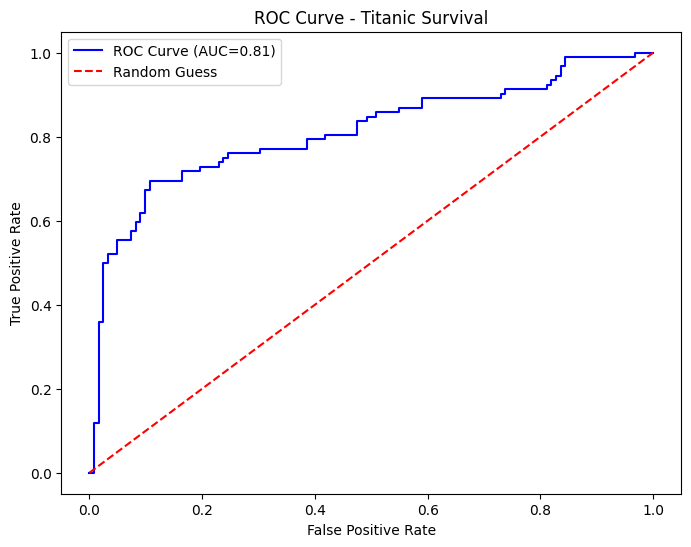

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']].dropna()
df['sex'] = df['sex'].map({'male':1,'female':0})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
X = df.drop('survived', axis=1)
y = df['survived']

XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.3, random_state=42)

logReg = LogisticRegression(max_iter=500)
logReg.fit(XTrain, yTrain)
yPred = logReg.predict(XTest)
yPredProb = logReg.predict_proba(XTest)[:,1]

print("Classification Report:\n", classification_report(yTest, yPred))
print("Confusion Matrix:\n", confusion_matrix(yTest, yPred))

fpr, tpr, thresholds = roc_curve(yTest, yPredProb)
rocAuc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC={rocAuc:.2f})')
plt.plot([0,1],[0,1], color='red', linestyle='--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Titanic Survival")
plt.legend()
plt.show()